In [81]:
# main file that works with Simulation.py

In [82]:
import cv2 as cv
import Simulation as S
from roi_config import rois
from scipy.optimize import least_squares
import numpy as np

In [83]:
import importlib
importlib.reload(S)

<module 'Simulation' from 'c:\\Users\\hallt3\\OneDrive - Rensselaer Polytechnic Institute\\Delay Line\\Inverse_Simulation\\Simulation.py'>

In [84]:
# Load whichever image you want
img_path = "images/N5D.jpg"

img_bgr = cv.imread(img_path)
gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

In [85]:
pts = S.reflec_pts_cam(gray, show=False)   # show=True if you want the ROI plots
pts

{'M1': [[375.27385892116183, 568.3900414937759],
  [379.7848101265823, 660.9145569620254]],
 'M2': [[1604.8348214285713, 344.2767857142857],
  [1599.8254716981132, 329.1179245283019]],
 'M3': [[307.5028571428571, 310.86857142857144],
  [321.2838709677419, 264.56774193548387]],
 'M4': [[1588.9507575757575, 689.2613636363636]]}

In [86]:
# Initialize mirror parameters:
M1 = [151, 109, 96.1312]
M2 = [20, 73, 96.2015]
M3 = [168, 69, 81.819]
M4 = [33, 120, 80.419]

NOT CLIPPED, room to spare:  6.74984895750443 mm
Laser Path: [(0, 100), (np.float64(151.96677968156126), np.float64(100.0)), (np.float64(20.178626139208717), np.float64(71.35611928144868)), (np.float64(168.39101190726387), np.float64(71.71982326531675)), (np.float64(31.68679947341434), np.float64(112.22020364243653)), (np.float64(151.25065111212768), np.float64(106.66662451417467)), (np.float64(20.138335378711275), np.float64(71.72691162242924)), (np.float64(167.46034854950125), np.float64(65.24626119317149)), (np.float64(-803.4938053475967), np.float64(304.51186889718514))]
Total Laser Length: 1152.9372053462994 mm
Total Number of Reflection (N_R) =  7


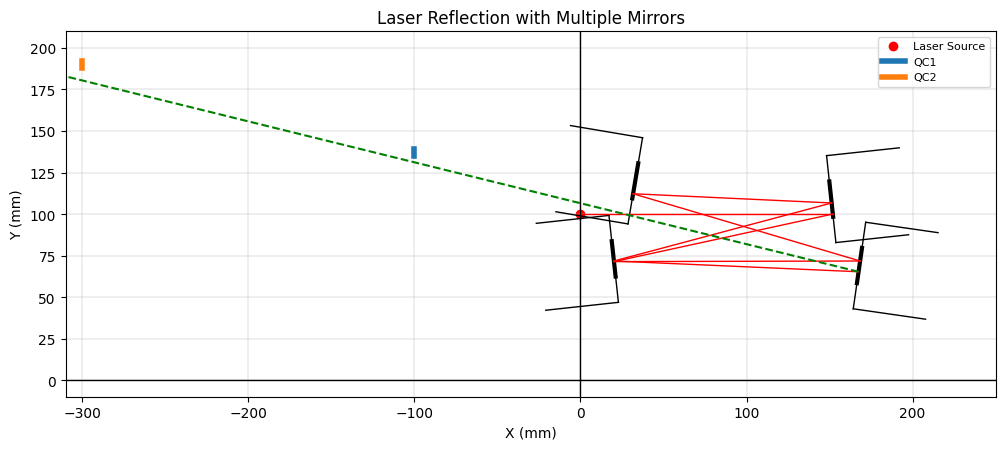

In [87]:
S.simulation(M1[0], M1[1], #M1, (x,y)
          M2[0], M2[1], #M2, (x,y)
          M3[0], M3[1], #M3, (x,y)
          M4[0], M4[1], #M4, (x,y)
          M1[2], M2[2], M3[2], M4[2]) # Angle from positive x-axis (M1, M2, M3, M4)

In [88]:
M1y, M2y, M3y, M4y = 109, 73, 69, 120 # simulation units (mm)

In [89]:
reflec_cam0 = S.reflec_pts_cam(gray, show=False)  # grouped dict now
K_by_mirror = {name: len(reflec_cam0[name]) for name in rois.keys()}

K_by_mirror

{'M1': 2, 'M2': 2, 'M3': 2, 'M4': 1}

In [90]:
%%time
# Initial guess
theta0 = np.array([M1[0], M2[0], M3[0], M4[0], M1[2], M2[2], M3[2], M4[2]], dtype=float)

res = least_squares(
    fun=lambda th: S.residuals(th, img_path_light="images/N5L.jpg", img_path_dark="images/N5D.jpg", K_by_mirror=K_by_mirror),
    x0=theta0,
    loss="huber",
    f_scale=1.0,
    verbose=2
)

theta_hat = res.x
print("theta_hat:", theta_hat)
print("final exit metric:", S.simulation_identifier(theta_hat[0], M1y, theta_hat[1], M2y, theta_hat[2], M3y, theta_hat[3], M4y,
                                                theta_hat[4], theta_hat[5], theta_hat[6], theta_hat[7]))

Exit angle: -0.2464231773906918
Total length: 1152.9372053462994
y100: -5.845309891238486
y200: -7.702992152169287
y300: -9.560674413100116
y525: -13.745459500194443
Exit angle: -0.24642317739069186
Total length: 1152.9372139306988
y100: -5.845311087677544
y200: -7.7029933486083735
y300: -9.560675609539203
y525: -13.7454606966335
Exit angle: -0.24642317739069186
Total length: 1152.9372042089005
y100: -5.845309734275418
y200: -7.702991995206219
y300: -9.56067425613702
y525: -13.745459343231346
Exit angle: -0.2464231773906918
Total length: 1152.9372154788566
y100: -5.845308648941085
y200: -7.702990909871886
y300: -9.560673170802716
y525: -13.745458257897042
Exit angle: -0.24642317739069183
Total length: 1152.93720435481
y100: -5.845310011601157
y200: -7.702992272531986
y300: -9.560674533462816
y525: -13.745459620557142
Exit angle: -0.2464230713129212
Total length: 1152.9371879481491
y100: -5.845395579361451
y200: -7.703088448069309
y300: -9.560781316777195
y525: -13.745590271369934
Exit 

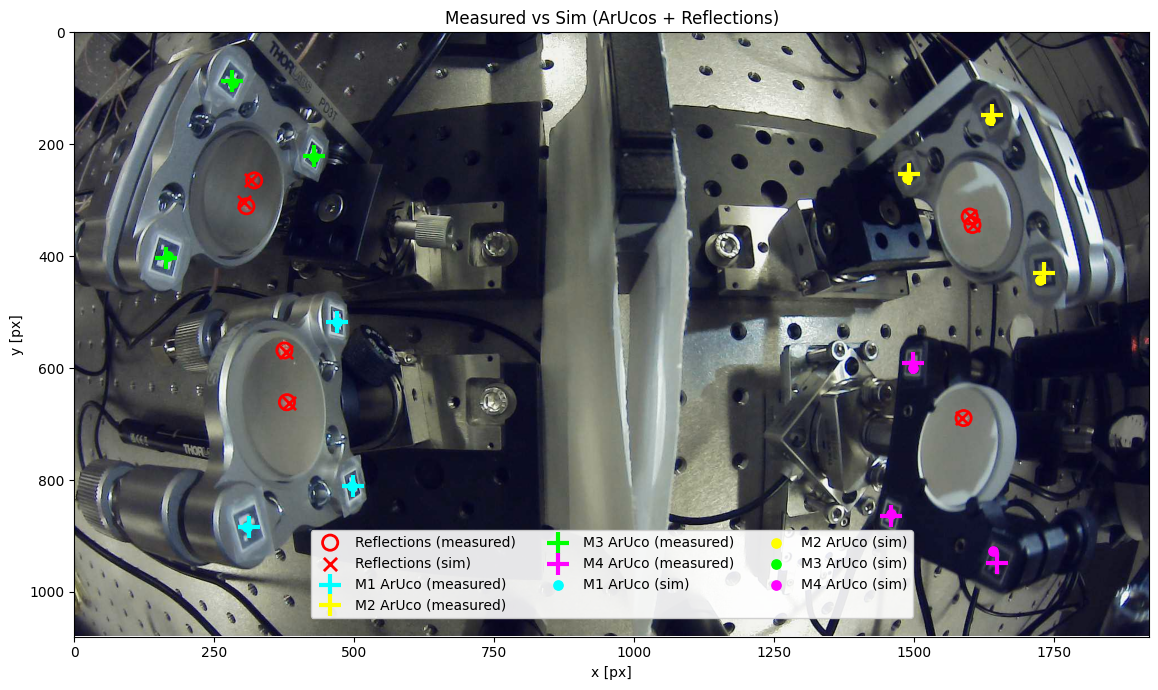

(<Figure size 1400x700 with 1 Axes>,
 <Axes: title={'center': 'Measured vs Sim (ArUcos + Reflections)'}, xlabel='x [px]', ylabel='y [px]'>)

In [92]:
# ---- Load images ----
img_light = cv.imread("images/N5L.jpg")
img_dark  = cv.imread("images/N5D.jpg")
gray = cv.cvtColor(img_dark, cv.COLOR_BGR2GRAY)

# ---- Measured points ----
aruco_centers_12 = S.camera_arucos("images/N5L.jpg")                 # list of 12
aruco_meas = S.group_aruco_centers_by_mirror(aruco_centers_12)

refl_meas = S.reflec_pts_cam(gray, show=False)                     # dict M1..M4

# ---- Sim points (from solved theta) ----
M1x, M2x, M3x, M4x, M1a, M2a, M3a, M4a = theta_hat

aruco_sim = S.sim_aruco_pts_by_mirror(M1x, M2x, M3x, M4x, M1a, M2a, M3a, M4a)
refl_sim  = S.sim_reflection_pts_by_mirror(M1x, M2x, M3x, M4x, M1a, M2a, M3a, M4a)

# ---- Overlay plot ----
S.overlay_reflections_and_aruco(
    img_bgr=img_light,
    reflec_meas_by_mirror=refl_meas,
    aruco_meas_by_mirror=aruco_meas,
    reflec_sim_by_mirror=refl_sim,
    aruco_sim_by_mirror=aruco_sim,
    title="Measured vs Sim (ArUcos + Reflections)"
)
